In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import time
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, Subset, ConcatDataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score, roc_curve

# --- Library Imports ---
sys.path.append('../') 
try:
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: conformalHDC modules not found. Ensure '../' is in path.")

In [2]:
@torch.no_grad()
def bipolar_sign(x):
    return torch.where(x >= 0, torch.ones_like(x), -torch.ones_like(x))

def make_position_hvs(n_positions, dim, device=None):
    device = device or DEVICE
    return (torch.randint(0, 2, (n_positions, dim), device=device, dtype=torch.float32) * 2 - 1)

@torch.no_grad()
def encode_binary_images_to_hvs(imgs, pos_hvs, threshold=0.5):
    B, C, H, W = imgs.shape
    x = (imgs.view(B, -1) >= threshold).to(torch.float32).to(pos_hvs.device)
    return bipolar_sign(x @ pos_hvs)

@torch.no_grad()
def build_prototypes(loader, pos_hvs, class_labels):
    D = pos_hvs.shape[1]
    n_classes = len(class_labels)
    accum = torch.zeros((n_classes, D), device=pos_hvs.device)
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(pos_hvs.device), labels.to(pos_hvs.device)
        hvs = encode_binary_images_to_hvs(imgs, pos_hvs)
        for i, lbl in enumerate(class_labels):
            m = (labels == lbl)
            if m.any():
                accum[i] += hvs[m].sum(dim=0)
    return bipolar_sign(accum)

@torch.no_grad()
def cosine_sim(a, b):
    a, b = a.float(), b.float()
    an = torch.norm(a, dim=1, keepdim=True).clamp_min(1e-8)
    bn = torch.norm(b, dim=1, keepdim=True).clamp_min(1e-8).T
    return (a @ b.T) / (an * bn)

def get_hvs_labels(loader, pos_hvs):
    all_hvs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(pos_hvs.device)
        hvs = encode_binary_images_to_hvs(imgs, pos_hvs)
        all_hvs.append(hvs.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_hvs), np.concatenate(all_labels)

In [9]:
def run_single_experiment(random_state, alpha):
    # Reproducibility
    np.random.seed(random_state)
    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
    
    # Data Prep & Splitting
    transform = transforms.ToTensor()
    raw_ds = ConcatDataset([
        datasets.MNIST(root='./data', train=True, transform=transform, download=True),
        datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    ])
    
    # Count labels
    all_targets = np.concatenate([d.targets.numpy() for d in raw_ds.datasets])
    unique_labels = np.unique(all_targets)    
    class_indices = [np.where(all_targets == i)[0] for i in unique_labels]
    min_count = min(len(idxs) for idxs in class_indices)
    
    # Subsample indices to ensure label balance
    balanced_indices = []
    rng = np.random.RandomState(random_state) 
    for idxs in class_indices:
        selected_idxs = rng.choice(idxs, min_count, replace=False)
        balanced_indices.extend(selected_idxs)
        
    ds_full = Subset(raw_ds, balanced_indices)
    targets = all_targets[balanced_indices]
    
    id_idx = np.where(np.isin(targets, LABELS_ID))[0]
    ood_idx = np.where(np.isin(targets, LABELS_OOD))[0]
    
    ds_id = Subset(ds_full, id_idx)
    ds_ood = Subset(ds_full, ood_idx)
    
    # Split in-distribution (IDs): 80% Train, 15% Calib, 5% Test
    n_total = len(ds_id)
    n_train = int(0.8 * n_total)
    n_calib = int(0.15 * n_total)
    n_test = n_total - n_train - n_calib
    
    ds_train, ds_calib, ds_test = random_split(
        ds_id, [n_train, n_calib, n_test], 
        generator=torch.Generator().manual_seed(random_state)
    )
    
    # Loaders
    ld_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
    ld_calib = DataLoader(ds_calib, batch_size=BATCH_SIZE, shuffle=False)
    ld_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
    ld_ood = DataLoader(ds_ood, batch_size=BATCH_SIZE, shuffle=False)
    
    # HDC Init
    pos_hvs = make_position_hvs(28*28, DIM, device=DEVICE)
    
    # Train Models
   # 1. Train Only (For ConformalHDC)
    protos_train = build_prototypes(ld_train, pos_hvs, LABELS_ID)
    
    # 2. Full (Train + Calib) (For Vanilla)
    ds_full_id = ConcatDataset([ds_train, ds_calib])
    ld_full = DataLoader(ds_full_id, batch_size=BATCH_SIZE, shuffle=True)
    protos_full = build_prototypes(ld_full, pos_hvs, LABELS_ID)
    print("Prototypes built.")
    sys.stdout.flush()

    # Pre-compute HVs
    calib_hvs, calib_y = get_hvs_labels(ld_calib, pos_hvs)
    test_hvs, test_y = get_hvs_labels(ld_test, pos_hvs)
    ood_hvs, ood_y = get_hvs_labels(ld_ood, pos_hvs)
    print("Encoding complete.")
    for label in LABELS_ID:
        print(f"label {label} test size: {np.sum(test_y==label)}")
    sys.stdout.flush()

    # Balance OOD to match Test size 
    min_len = min(len(ood_hvs), len(test_hvs))
    ood_hvs, ood_y = ood_hvs[:min_len], ood_y[:min_len]
    
    chdc = ConformalHDC(protos_train.cpu().numpy(), LABELS_ID, sim_measure="cosine", random_state=random_state) 
    
    exp_results = []
    
    # --- Experiment Loop per Score Type ---
    for stype in SCORE_TYPES:
        chdc.compute_calib_scores(calib_hvs, calib_y, score_type=stype)
        
        # 1. Set-Valued Prediction
        for marginal in [True, False]:
            sets = chdc.set_valued_CP(test_hvs, alpha, marginal=marginal)
            sizes = [len(p) for p in sets]
            covered = [1 if y in p else 0 for y, p in zip(test_y, sets)]
            
            # Label conditional coverage
            lc_covs = []
            for lbl in LABELS_ID:
                lbl_idx = np.where(test_y == lbl)[0]
                if len(lbl_idx) > 0:
                    lc_covs.append(np.mean([covered[i] for i in lbl_idx]))
            
            exp_results.append({
                "exp": "set_valued",
                "random_state": random_state,
                "score_type": stype,
                "alpha": alpha,
                "marginal": marginal,
                "set_cov": np.mean(covered),
                "set_size": np.mean(sizes),
                "lc_covs": lc_covs if lc_covs else 0.0,
                # Placeholders
                "point_acc": np.nan, "lc_accs":np.nan, "ood_auroc": np.nan
            })
            
        # 2. Point-Valued Prediction
        preds_pt = chdc.point_valued_CP(test_hvs, alpha, allow_empty=False, marginal=False)
        acc_pt = eval_accuracy(np.array(preds_pt).ravel(), test_y)
        lc_accs = eval_lc_accuracy(preds_pt, test_y, LABELS_ID)

        exp_results.append({
            "exp": "point_valued",
            "random_state": random_state,
            "score_type": stype,
            "alpha": alpha,
            "point_acc": acc_pt,
            "lc_accs": lc_accs,
            # Placeholders
            "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
            "lc_covs": np.nan, "ood_auroc": np.nan
        })

        # 3. OOD Detection
        for marginal in [True, False]:
            p_vals_id = chdc.get_max_p_value(test_hvs, marginal=marginal)
            p_vals_ood = chdc.get_max_p_value(ood_hvs, marginal=marginal)
            
            y_true_roc = np.concatenate([np.ones(len(p_vals_id)), np.zeros(len(p_vals_ood))])
            y_scores_roc = np.concatenate([p_vals_id, p_vals_ood])
            
            ood_auroc = roc_auc_score(y_true_roc, y_scores_roc)
            
            exp_results.append({
                "exp": "ood",
                "random_state": random_state,
                "score_type": stype,
                "alpha": alpha,
                "marginal": marginal,
                "ood_auroc": ood_auroc,
                # Placeholders
                "set_cov": np.nan, "set_size": np.nan, "point_acc": np.nan, 
                "lc_covs": np.nan, "lc_accs":np.nan
            })
    print("Finished running ConformalHDC.")
    sys.stdout.flush()

    # Baseline Vanilla HDC (Once per seed)
    preds_vanilla = chdc.predict(test_hvs)
    acc_vanilla = eval_accuracy(preds_vanilla, test_y)
    lc_accs = eval_lc_accuracy(preds_vanilla, test_y, LABELS_ID)
    
    exp_results.append({
        "exp": "point_valued",
        "random_state": random_state,
        "score_type": "vanilla_train",
        "alpha": np.nan,
        "point_acc": acc_vanilla, 
        "lc_accs": lc_accs,
        # Placeholders
        "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
        "lc_covs": np.nan, "ood_auroc": np.nan
    })

    chdc_full = ConformalHDC(protos_full.cpu().numpy(), LABELS_ID, sim_measure="cosine", random_state=random_state)
    preds_vanilla = chdc_full.predict(test_hvs)
    acc_vanilla = eval_accuracy(preds_vanilla, test_y)
    lc_accs = eval_lc_accuracy(preds_vanilla, test_y, LABELS_ID)
    
    exp_results.append({
        "exp": "point_valued",
        "random_state": random_state,
        "score_type": "vanilla_full",
        "alpha": np.nan,
        "point_acc": acc_vanilla, 
        "lc_accs": lc_accs,
        # Placeholders
        "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
        "lc_covs": np.nan, "ood_auroc": np.nan
    })
    
    print("Finished running vanilla HDC.")
    sys.stdout.flush()

    return pd.DataFrame(exp_results)

In [10]:
EXP_NAME = "mnist"
REPETITIONS = 5
DIM = 10_000
BATCH_SIZE = 512
LABELS_ID = [ 1, 2, 3, 4, 5]
LABELS_OOD = [0, 6, 7, 8, 9]
#SCORE_TYPES = ["sim", "ratio", "discount", "penalized", "inverse_quantile"]
SCORE_TYPES = ["sim", "ratio", "discount"]
ALPHA = 0.05
SEED = 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Repetitions:   0%|                                                                               | 0/5 [00:00<?, ?it/s]

Running repetition 1...
Prototypes built.
Encoding complete.
label 1 test size: 344
label 2 test size: 327
label 3 test size: 284
label 4 test size: 316
label 5 test size: 308
> c:\users\liang\appdata\local\temp\ipykernel_18392\1250062808.py(118)run_single_experiment()



ipdb>  ls


*** NameError: name 'ls' is not defined


ipdb>  l


...

ipdb>  sim=chdc._sim(test_hvs,chdc.class_HVs[0])
ipdb>  sim


array([0.6668    , 0.64890003, 0.6687    , ..., 0.6796    , 0.649     ,
       0.5841    ], dtype=float32)


ipdb>  plt.hist(sim)


(array([ 33., 120., 275., 432., 283., 140.,  86.,  67.,  88.,  55.]), array([0.52869999, 0.56036997, 0.59204   , 0.62370998, 0.65538001,
       0.68704998, 0.71871996, 0.75038993, 0.78205997, 0.81373   ,
       0.84539998]), <BarContainer object of 10 artists>)


ipdb>  plt.show()


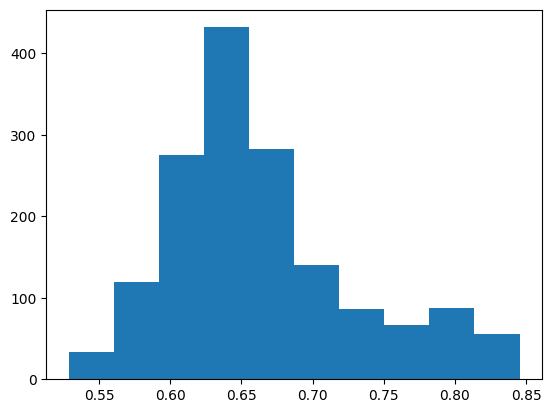

ipdb>  plt.hist(sim*2-1)


(array([ 33., 120., 275., 432., 283., 140.,  86.,  67.,  88.,  55.]), array([0.05739999, 0.12073998, 0.18407997, 0.24741997, 0.31075996,
       0.37409997, 0.43743995, 0.50077993, 0.56411994, 0.62745994,
       0.69079995]), <BarContainer object of 10 artists>)


ipdb>  plt.show()


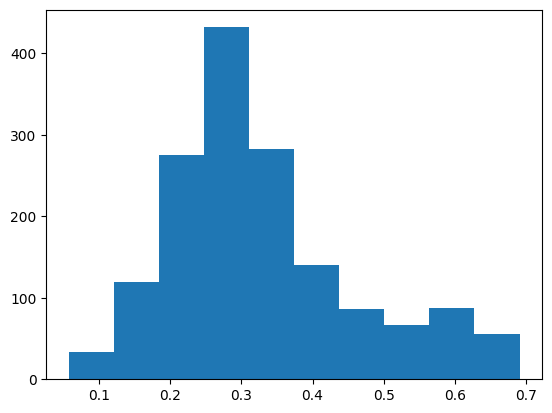

ipdb>  sim=chdc._sim(test_hvs,chdc.class_HVs[1])
ipdb>  plt.hist(sim*2-1)


(array([ 15., 118., 353., 466., 266., 178.,  93.,  64.,  20.,   6.]), array([0.14919996, 0.20329997, 0.25739998, 0.31149995, 0.36559996,
       0.41969997, 0.47379994, 0.52789998, 0.58199996, 0.63609993,
       0.69019997]), <BarContainer object of 10 artists>)


ipdb>  plt.show()


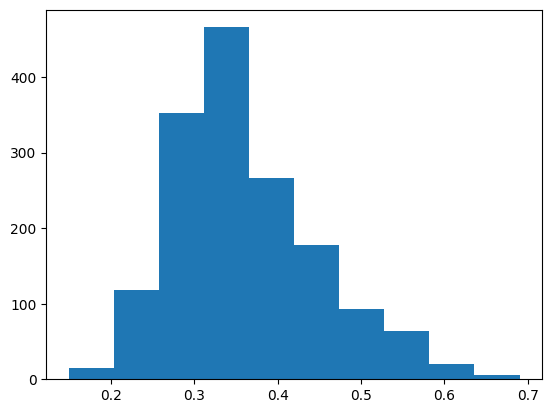

ipdb>  sim=chdc._sim(test_hvs,chdc.class_HVs[2])
ipdb>  plt.hist(sim*2-1)


(array([  7.,  39., 187., 425., 379., 237., 142., 108.,  44.,  11.]), array([0.10099995, 0.15837994, 0.21575995, 0.27313995, 0.33051994,
       0.38789994, 0.44527996, 0.50265992, 0.56003994, 0.61741996,
       0.67479992]), <BarContainer object of 10 artists>)


ipdb>  plt.show()


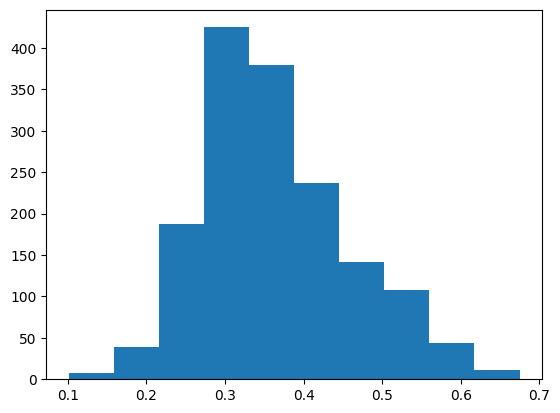

ipdb>  q


Error in state 1: 


Repetitions:  20%|██████████████                                                        | 1/5 [03:16<13:04, 196.23s/it]

Running repetition 2...
Prototypes built.
Encoding complete.
label 1 test size: 351
label 2 test size: 316
label 3 test size: 309
label 4 test size: 316
label 5 test size: 287


In [ ]:
results_list = []

for i in tqdm(range(1, REPETITIONS + 1), desc="Repetitions"):
    # Generate unique seed based on group ID and repetition index
    print(f"Running repetition {i}...")
    sys.stdout.flush()
    current_state = REPETITIONS * (SEED - 1) + i
    
    try:
        df_rep = run_single_experiment(current_state, ALPHA)
        results_list.append(df_rep)
    except Exception as e:
        print(f"Error in state {current_state}: {e}")
        sys.stdout.flush()

In [6]:
final_df = pd.concat(results_list, ignore_index=True)

In [7]:
final_df

,exp,random_state,score_type,alpha,marginal,set_cov,set_size,lc_covs,point_acc,lc_accs,ood_auroc
0,set_valued,1,sim,0.05,True,0.939835,2.876504,"[0.9593023255813954, 0.9663608562691132, 0.947...",NaN,NaN,NaN
1,set_valued,1,sim,0.05,False,0.940469,2.796073,"[0.9447674418604651, 0.963302752293578, 0.9366...",NaN,NaN,NaN
2,point_valued,1,sim,0.05,NaN,NaN,NaN,NaN,0.864471,"[0.9273255813953488, 0.8899082568807339, 0.852...",NaN
3,ood,1,sim,0.05,True,NaN,NaN,NaN,NaN,NaN,0.687334
4,ood,1,sim,0.05,False,NaN,NaN,NaN,NaN,NaN,0.572481
...,...,...,...,...,...,...,...,...,...,...,...
80,point_valued,5,discount,0.05,NaN,NaN,NaN,NaN,0.867004,"[0.9313725490196079, 0.8619528619528619, 0.860...",NaN
81,ood,5,discount,0.05,True,NaN,NaN,NaN,NaN,NaN,0.718580
82,ood,5,discount,0.05,False,NaN,NaN,NaN,NaN,NaN,0.584187
83,point_valued,5,vanilla_train,NaN,NaN,NaN,NaN,NaN,0.861938,"[0.9313725490196079, 0.8653198653198653, 0.860...",NaN


In [8]:
# 1. Filter & Expand Data
df_pt = final_df[final_df['exp'] == 'point_valued'].copy()

# Convert list column to individual columns (one per class)
acc_matrix = pd.DataFrame(df_pt['lc_accs'].tolist(), index=df_pt.index)
acc_matrix.columns = [f"Class_{lbl}" for lbl in LABELS_ID] # Rename cols
acc_matrix['Method'] = df_pt['score_type']

# 2. Aggregate (Mean across seeds)
grouped = acc_matrix.groupby('Method').mean()

# 3. Calculate Difference (Method - Vanilla_Full)
if 'vanilla_full' in grouped.index:
    baseline = grouped.loc['vanilla_train']
    diff_df = grouped.sub(baseline, axis=1)
else:
    diff_df = grouped # Fallback if baseline missing

# 4. Display "Quick & Dirty" Heatmap
# RdYlGn colormap: Red (negative), Yellow (zero), Green (positive)
diff_df.style.background_gradient(cmap='RdYlGn', axis=None, vmin=-0.1, vmax=0.1) \
             .format("{:+.2%}")

,Class_1,Class_2,Class_3,Class_4,Class_5
Method,,,,,
discount,-0.17%,+0.06%,-0.56%,-0.71%,+2.36%
ratio,-0.12%,+0.18%,+0.24%,-1.15%,+0.97%
sim,-0.52%,-0.06%,-0.94%,-0.65%,+3.00%
vanilla_full,-0.13%,-0.06%,-0.25%,+0.20%,+0.44%
vanilla_train,+0.00%,+0.00%,+0.00%,+0.00%,+0.00%
